In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

C:\Users\admin\Anaconda3\lib\site-packages\statsmodels\tools\_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [2]:
data = pd.read_csv(r'E:\WiproVIT2020\Creditt card\credit_card/creditcard.csv')
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [3]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
data.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [5]:
# Check the shape of the data
data.shape

(284807, 31)

In [6]:
# Check null values
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
# Check the data summary
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,3.919560e-15,5.688174e-16,-8.769071e-15,2.782312e-15,-1.552563e-15,2.010663e-15,-1.694249e-15,-1.927028e-16,-3.137024e-15,...,1.537294e-16,7.959909e-16,5.367590e-16,4.458112e-15,1.453003e-15,1.699104e-15,-3.660161e-16,-1.206049e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
print("Fraud Statistics")

avg_amt = data[data['Class']== 1]['Amount'].mean()
std_dev_amt = data[data['Class']== 1]['Amount'].std()
min_amt = data[data['Class']== 1]['Amount'].min()
max_amt = data[data['Class']== 1]['Amount'].max()

print(f"The average amount is {avg_amt}")
print(f"The std deviation for amount is {std_dev_amt}")
print(f"The min amount is {min_amt}")
print(f"The max amount is {max_amt}")

Fraud Statistics
The average amount is 122.21132113821133
The std deviation for amount is 256.68328829771207
The min amount is 0.0
The max amount is 2125.87


In [9]:
# Check classes counts
data['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [10]:
# Percentage
print(f'Non-Fraud is: {100*284315/(284315+492)}%')

Non-Fraud is: 99.827251436938%


<AxesSubplot:xlabel='Time'>

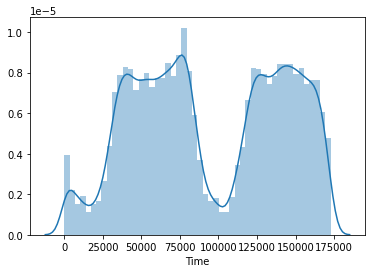

In [11]:
sns.distplot(data['Time'])

<AxesSubplot:xlabel='Amount'>

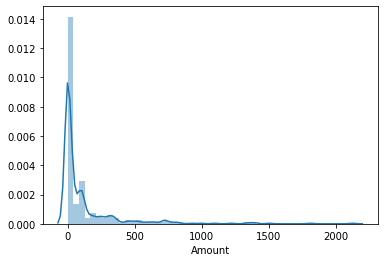

In [12]:
sns.distplot(data[data['Class'] == 1]['Amount'])

In [13]:
# Model Training and Evaluation
dataC = data.copy()

In [14]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

dataC[['Time', 'Amount']] = sc.fit_transform(dataC[['Time', 'Amount']])

In [15]:
# #Data Splitting
# As we saw before, 99.8% of the data is non-fraud, which may result in a pure non-fraud testing data, so will follow the followung steps:
# Separate the fraud observation from the original datset.
# Split the fraud observation into training and testing datasets.
# Split the non-fraud observations into training and testing datasets.
# Combine fraud and non0fraud for each subsets.
# Shuffel them.

In [16]:
frauds = dataC[dataC['Class']==1].copy()
non_frauds = dataC[dataC['Class']==0].copy()


In [17]:
x_train_fraud = frauds.sample(frac=0.8, random_state=27)
x_test_fraud = frauds.loc[~frauds.index.isin(x_train_fraud.index)]

x_train_non_fraud = non_frauds.sample(frac=0.8, random_state=27)
x_test_non_fraud = non_frauds.loc[~non_frauds.index.isin(x_train_non_fraud.index)]

In [18]:
print(f'Train \'fraud\' shape is: {x_train_fraud.shape}')
print(f'Test \'fraud\' shape is: {x_test_fraud.shape}')
print(f'Train \'non-fraud\' shape is: {x_train_non_fraud.shape}')
print(f'Test \'non-fraud\' shape is: {x_test_non_fraud.shape}')

Train 'fraud' shape is: (394, 31)
Test 'fraud' shape is: (98, 31)
Train 'non-fraud' shape is: (227452, 31)
Test 'non-fraud' shape is: (56863, 31)


In [19]:
train = pd.concat([x_train_non_fraud, x_train_fraud])
test = pd.concat([x_test_non_fraud, x_test_fraud])

In [20]:
# Shuffle dataframes in-place and reset the index
train = train.sample(frac=1, random_state=27).reset_index(drop=True)
test = test.sample(frac=1, random_state=27).reset_index(drop=True)

In [21]:
print(f'Original size is: {data.shape}')
print(f'Train size is: {train.shape} with perc = {train.shape[0]/data.shape[0]}')
print(f'Test size is: {test.shape} with perc = {test.shape[0]/data.shape[0]}')

Original size is: (284807, 31)
Train size is: (227846, 31) with perc = 0.8000014044598623
Test size is: (56961, 31) with perc = 0.1999985955401377


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support


In [29]:
# Initializing empty lists to append all model's name and corresponding name
acc = []
model = []

In [23]:
def evaluate_model(labels, preds):
    accuracy = (preds == labels).sum() / preds.shape[0]
    print(f'Accuracy: {accuracy}')

    auc = roc_auc_score(labels, preds)
    print(f'AUC     : {auc}')

    precision, recall, f1_score, _ = precision_recall_fscore_support(labels, preds, average = 'binary')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1_score: {f1_score}')

    confusion_matrix = pd.crosstab(index=labels, columns=np.round(preds), 
                                   rownames=['True'], colnames=['predictions']).astype(int)
    plt.figure(figsize = (5,5))
    sns.heatmap(confusion_matrix, annot=True, fmt='.2f', cmap="YlGnBu").set_title('Confusion Matrix') 
    
    return {'Accuracy':accuracy, 'Auc':auc, 'Precicion':precision, 'Recall':recall, 'F1_Score':f1_score}

In [24]:
xtrain = train.drop(columns=['Class'], axis=1)
ytrain = train.Class

xtest = test.drop(columns=['Class'], axis=1)
ytest = test.Class

Accuracy: 0.9991046505503766
AUC     : 0.7907283958903013
Precision: 0.8507462686567164
Recall: 0.5816326530612245
F1_score: 0.6909090909090908


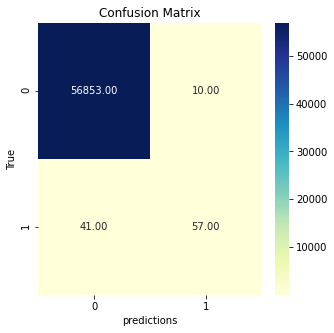

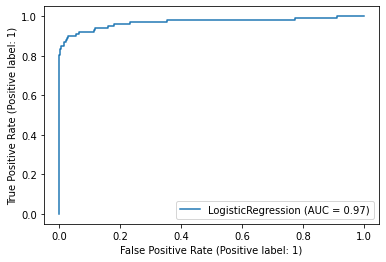

In [37]:
logReg_base = LogisticRegression()
logReg_base.fit(xtrain, ytrain)

predictions_base = logReg_base.predict(xtest)
x = metrics.accuracy_score(ytest, predictions_base)
acc.append(x)
model.append('Logistic regression')
result_base = evaluate_model(ytest, predictions_base)
metrics.plot_roc_curve(logReg_base, xtest, ytest) 

DecisionTrees's Accuracy is:  99.9350432752234
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.90      0.70      0.79        98

    accuracy                           1.00     56961
   macro avg       0.95      0.85      0.89     56961
weighted avg       1.00      1.00      1.00     56961

Accuracy: 0.999350432752234
AUC     : 0.8519704718142819
Precision: 0.8961038961038961
Recall: 0.7040816326530612
F1_score: 0.7885714285714286


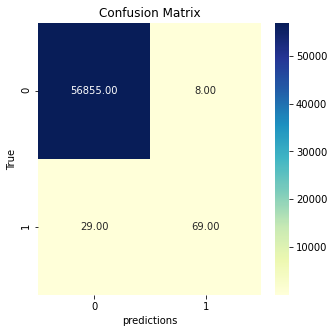

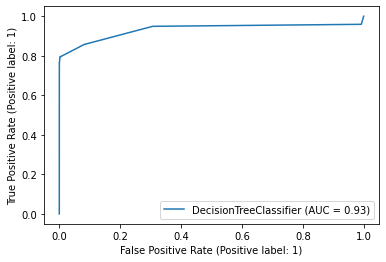

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import classification_report
DecisionTree = DecisionTreeClassifier(criterion="entropy",random_state=2,max_depth=5)

DecisionTree.fit(xtrain,ytrain)

predicted_values = DecisionTree.predict(xtest)
x = metrics.accuracy_score(ytest, predicted_values)
acc.append(x)
model.append('Decision Tree')
print("DecisionTrees's Accuracy is: ", x*100)

print(classification_report(ytest,predicted_values))
result_base = evaluate_model(ytest, predicted_values)
metrics.plot_roc_curve(DecisionTree, xtest, ytest) 

Naive Bayes's Accuracy is:  0.9785116132090378
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56863
           1       0.06      0.84      0.12        98

    accuracy                           0.98     56961
   macro avg       0.53      0.91      0.55     56961
weighted avg       1.00      0.98      0.99     56961

Accuracy: 0.9785116132090378
AUC     : 0.9077453255892161
Precision: 0.06356589147286822
Recall: 0.8367346938775511
F1_score: 0.11815561959654179


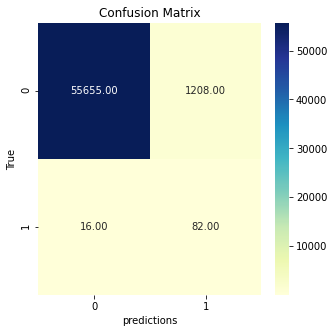

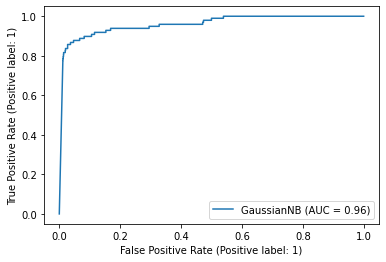

In [39]:
from sklearn.naive_bayes import GaussianNB

NaiveBayes = GaussianNB()

NaiveBayes.fit(xtrain,ytrain)

predicted_values = NaiveBayes.predict(xtest)
x = metrics.accuracy_score(ytest, predicted_values)
acc.append(x)
model.append('Naive Bayes')
print("Naive Bayes's Accuracy is: ", x)

print(classification_report(ytest,predicted_values))
result_base = evaluate_model(ytest, predicted_values)
metrics.plot_roc_curve(NaiveBayes, xtest, ytest) 

KNN Accuracy is:  0.9995084355962852
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.95      0.76      0.84        98

    accuracy                           1.00     56961
   macro avg       0.97      0.88      0.92     56961
weighted avg       1.00      1.00      1.00     56961

Accuracy: 0.9995084355962852
AUC     : 0.8775158481520389
Precision: 0.9487179487179487
Recall: 0.7551020408163265
F1_score: 0.8409090909090908


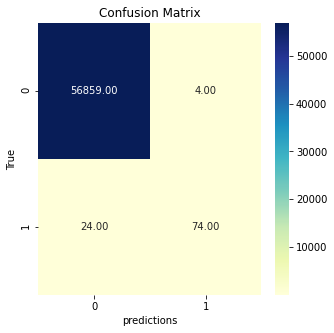

In [34]:
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=3)

neigh.fit(xtrain,ytrain)

predicted_values = neigh.predict(xtest)
x = metrics.accuracy_score(ytest, predicted_values)
acc.append(x)
model.append('KNN')
print("KNN Accuracy is: ", x)

print(classification_report(ytest,predicted_values))
result_base = evaluate_model(ytest, predicted_values)
metrics.plot_roc_curve(neigh, xtest, ytest) 

<AxesSubplot:title={'center':'Accuracy Comparison 80% Train and 20% Test Dataset'}, xlabel='Accuracy', ylabel='Algorithm'>

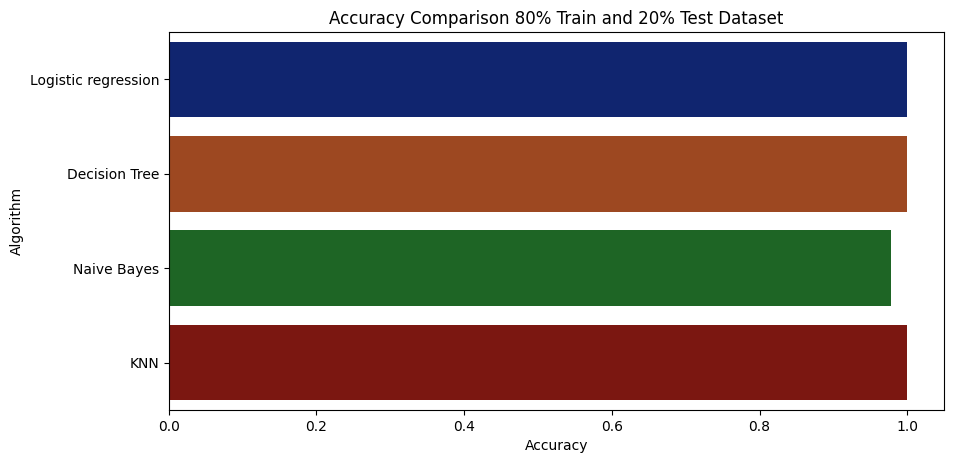

In [35]:
plt.figure(figsize=[10,5],dpi = 100)
plt.title('Accuracy Comparison 80% Train and 20% Test Dataset')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')
sns.barplot(x = accuracy,y = model,palette='dark')

Text(0.5, 1.0, 'Original Distribution of the dataset')

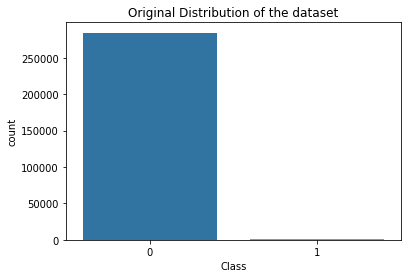

In [26]:
sns.countplot(x=data['Class'])
plt.title('Original Distribution of the dataset')

In [27]:
# There are two main ways to handle imbalanced datasets:

# Undersample to reduce the negative samples
# Random undersampling.
# Generate centroids using clustering methods.

# Oversample to add more positive samples:
# Random oversampling.
# Synthetic minority oversampling technique (SMOTE).
# NOTE: Sampling will be performed on training and testing data separately to avoid data leakage.

In [27]:
from imblearn.under_sampling import RandomUnderSampler

'''
xtrain: training features
ytrain: training labels

xtest: testinf features
ytest: testing labels
'''

rus = RandomUnderSampler(random_state=27)

# Undersample the training data
X_rus, Y_rus = rus.fit_resample(xtrain, ytrain) 
rus_train = pd.DataFrame(X_rus)
rus_train['Class'] = Y_rus

# Undersample the testing data
x_rus, y_rus = rus.fit_resample(xtest, ytest) 
rus_test = pd.DataFrame(x_rus)
rus_test['Class'] = y_rus

# Shuffle the data
rus_train = rus_train.sample(frac=1, random_state=345).reset_index(drop=True)
rus_test = rus_test.sample(frac=1, random_state=345).reset_index(drop=True)

rus_train.head()

KeyboardInterrupt: 

In [ ]:
print(f'Original size: {train.shape[0]}')
print(f'New size: {rus_train.shape[0]}')
print(f'Removed: {rus_train.shape[0]-data.shape[0]}')

In [ ]:
sns.countplot(x=rus_train['Class'])

In [ ]:
plt.figure(figsize = (27,17))
rus_correlation_matrix = rus_train.corr()
sns.heatmap(rus_correlation_matrix, annot=True, fmt=".2f")

In [ ]:
# V18, V17 ---> highly correlated 0.94 ---> ∴ remove one of them.
# V18, V16 ---> highly correlated 0.91 ---> ∴ remove one of them.
# V17, V16 ---> highly correlated 0.95 ---> ∴ remove one of them.
# V16, V12 ---> highly correlated 0.91 ---> ∴ remove one of them.
# ∴ Remove V16, V18

In [ ]:
xtrain_rus = rus_train.drop(columns=['V16', 'V18', 'Class'], axis=1)
ytrain_rus = rus_train['Class']

In [ ]:
logReg_rus = LogisticRegression()
logReg_rus.fit(xtrain_rus, ytrain_rus)

In [ ]:
# For the testing data
xtest_rus = rus_test.drop(columns=['V16', 'V18', 'Class'], axis=1)
ytest_rus = rus_test['Class']

predictions_rus = logReg_rus.predict(xtest_rus)
result_rus = evaluate_model(ytest_rus, predictions_rus)

In [ ]:

acc = []
model = []

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import classification_report
DecisionTree = DecisionTreeClassifier(criterion="entropy",random_state=2,max_depth=5)

DecisionTree.fit(xtrain,ytrain)

predicted_values = DecisionTree.predict(xtest)
x = metrics.accuracy_score(ytest, predicted_values)
acc.append(x)
model.append('Decision Tree')
print("DecisionTrees's Accuracy is: ", x*100)

print(classification_report(ytest,predicted_values))
result_base = evaluate_model(ytest, predicted_values)

In [ ]:
from sklearn.naive_bayes import GaussianNB

NaiveBayes = GaussianNB()

NaiveBayes.fit(xtrain,ytrain)

predicted_values = NaiveBayes.predict(xtest)
x = metrics.accuracy_score(ytest, predicted_values)
acc.append(x)
model.append('Naive Bayes')
print("Naive Bayes's Accuracy is: ", x)

print(classification_report(ytest,predicted_values))
result_base = evaluate_model(ytest, predicted_values)

In [1]:
from keras.models import Sequential
from keras.layers import Dense

# Neural Networks# Neural 
neural = MLPClassifier(hidden_layer_sizes=40,
                     activation='relu',
                     solver='adam',
                     alpha=0.001,
                     batch_size='auto',
                     max_iter=200,
                     random_state=137,
                     tol=0.0001,
                     early_stopping=False,
                     validation_fraction=0.1,
                     beta_1=0.9,
                     beta_2=0.999,
                     epsilon=1e-08,
                     learning_rate='constant',
                     power_t=0.5,
                     momentum=0.8,
                     nesterovs_momentum=True,
                     shuffle=True,
                     learning_rate_init=0.001)
neural.fit(X_train, y_train)
#Predict Output
predicted = neural.predict(X_test)

neural_score = round(neural.score(X_train, y_train) * 100, 2)
neural_score_test = round(neural.score(X_test, y_test) * 100, 2)
print('Neural Score: \n', neural_score)
print('Neural Test Score: \n', neural_score_test)
print('Accuracy: \n', accuracy_score(y_test, predicted))
print(confusion_matrix(predicted,y_test))
print(classification_report(y_test,predicted))

NameError: name 'MLPClassifier' is not defined

In [ ]:
yhat=model.predict(xtest)
from sklearn.metrics import r2_score
print("R2 aquare",r2_score(ytest, yhat))
acc.append(r2_score(ytest, yhat))
from sklearn.metrics import mean_absolute_error

print("Mean Absolute Error", mean_absolute_error(ytest, yhat))

from sklearn.metrics import mean_squared_error
mean_squared_error= mean_squared_error(ytest, yhat)
print("Mean Squared Erorr", mean_squared_error)

from math import sqrt
rootMeanSquaredError = sqrt(mean_squared_error)
print("Root Mean Squared Error",rootMeanSquaredError)